/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc


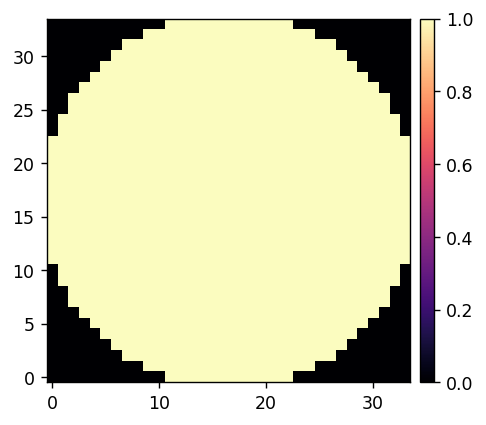

In [ ]:
import numpy as np
import astropy.units as u
from astropy.io import fits
import time 
from importlib import reload
import copy
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize, CenteredNorm
from matplotlib.patches import Circle, Rectangle

import scoob_llowfsc
print(scoob_llowfsc.path)
data_path = scoob_llowfsc.path/'exp-data'

from scoob_llowfsc.math_module import xp, xcipy, ensure_np_array
from scoob_llowfsc import utils
from scoob_llowfsc import dm
from scoob_llowfsc import telem
import scoob_llowfsc.scoob_interface as scoobi

from magpyx.utils import ImageStream

import purepyindi
from purepyindi import INDIClient
import purepyindi2
from purepyindi2 import IndiClient
client0 = INDIClient('localhost', 7624)
client0.start()
client = IndiClient()
client.connect()
client.get_properties()

dm00_stream = ImageStream('dm00disp00')
dm01_stream = ImageStream('dm00disp01')
dm02_stream = ImageStream('dm00disp02')
dm03_stream = ImageStream('dm00disp03')

camsci_stream = ImageStream('camsci')
camlo_stream = ImageStream('camlo')

wavelength_c = 633e-9
camsci_pxscl = 4.6e-6
camsci_pxscl_lamDc = 0.307

from scoob_llowfsc import dm
dm_mask = ensure_np_array(dm.make_mask(34))
utils.imshow([dm_mask])

In [68]:
scoobi.zero_dm(dm02_stream)

In [2]:
reload(scoobi)
# xc, yc = (5500, 3100)
# xc, yc = (4000, 2500)
# npsf = 1500
# npsf = 2048

xc, yc = (5450, 1100) # 1005, 1125
npsf = 2048
scoobi.set_cam_roi(xc, yc, npsf, client0, cam_name='camsci', bin_mode=2)

scoobi.set_cam_exp_time(0.01, client0, cam_name='camsci',)
scoobi.set_cam_gain(300, client0, cam_name='camsci',)
scoobi.set_cam_blacklevel(1, client0, cam_name='camsci',)

Set camsci ROI.
Set the camsci exposure time to 1.00e-02s
Set the camsci gain setting to 300.0
Set the camsci blacklevel to 1.0


In [31]:
scoobi.set_cam_exp_time(0.02, client0, cam_name='camsci',)

Set the camsci exposure time to 2.00e-02s


In [3]:
reload(scoobi)
xc, yc = (3900, 2575)
npsf = 256
scoobi.set_cam_roi(xc, yc, npsf, client0, cam_name='camlo', bin_mode=2)
scoobi.set_cam_exp_time(0.005, client0, cam_name='camlo',)
scoobi.set_cam_gain(120, client0, cam_name='camlo',)
scoobi.set_cam_blacklevel(2, client0, cam_name='camlo',)

Set camlo ROI.
Set the camlo exposure time to 5.00e-03s
Set the camlo gain setting to 120.0
Set the camlo blacklevel to 2.0


In [63]:
reload(scoobi)
xc, yc = (3900, 2575)
npsf = 1024
scoobi.set_cam_roi(xc, yc, npsf, client0, cam_name='camlo', bin_mode=2)
scoobi.set_cam_exp_time(0.005, client0, cam_name='camlo',)
scoobi.set_cam_gain(120, client0, cam_name='camlo',)
scoobi.set_cam_blacklevel(1, client0, cam_name='camlo',)

Set camlo ROI.
Set the camlo exposure time to 5.00e-03s
Set the camlo gain setting to 120.0
Set the camlo blacklevel to 1.0


In [71]:
scoobi.zero_dm(dm01_stream)

In [32]:
scoobi.set_fib_atten(0, client)

Set the fiber attenuation to 0.0


In [93]:
scoobi.move_psf(2, 0, client0)

In [89]:
scoobi.move_psf(0, 2, client0)

In [45]:
scoobi.move_psf(-10,0, client0)

In [48]:
scoobi.move_psf(0, 10, client0)

In [49]:
reload(scoobi)
scoobi.set_fib_atten(0, client)
scoobi.set_cam_exp_time(0.005, client0, cam_name='camlo',)
scoobi.set_cam_gain(120, client0, cam_name='camlo',)
scoobi.set_cam_blacklevel(1, client0, cam_name='camlo',)


Set the fiber attenuation to 0.0
Set the camlo exposure time to 5.00e-03s
Set the camlo gain setting to 120.0
Set the camlo blacklevel to 1.0


In [5]:
scoobi.set_camsci_blacklevel(1, client0)

Set the CAMSCI blacklevel to 1.0


In [ ]:
new_flat = ensure_np_array(utils.load_fits('20250324_flat.fits'))

dm00_stream.write(new_flat)



# Make the Fourier modes

0


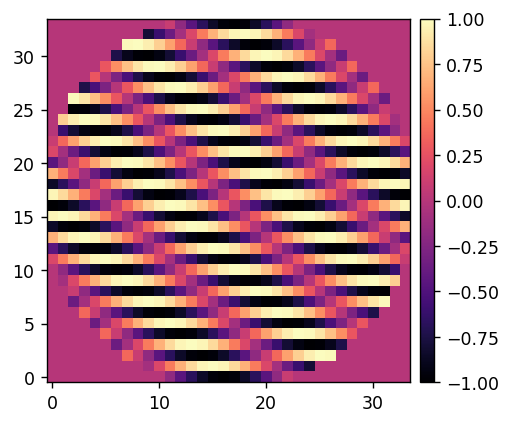

In [203]:
reload(dm)

iwa = 2
owa = 15

cos_modes = dm.create_fourier_modes(
    xp.array(dm_mask), 
    npsf, 
    camsci_pxscl_lamDc, 
    iwa, 
    owa, 
    rotation=0, 
    fourier_sampling=1,
    which='cos', 
    return_fs=False,
)

utils.imshow(
    [cos_modes[0]]
)

In [59]:
# xc, yc = (5450, 1100) # 1005, 1125
# npsf = 2048
# scoobi.set_cam_roi(xc, yc, npsf, client0, cam_name='camsci', bin_mode=2)

scoobi.set_cam_exp_time(0.01, client0, cam_name='camsci',)
scoobi.set_cam_gain(120, client0, cam_name='camsci',)
scoobi.set_cam_blacklevel(1, client0, cam_name='camsci',)

Set the camsci exposure time to 1.00e-02s
Set the camsci gain setting to 120.0
Set the camsci blacklevel to 1.0


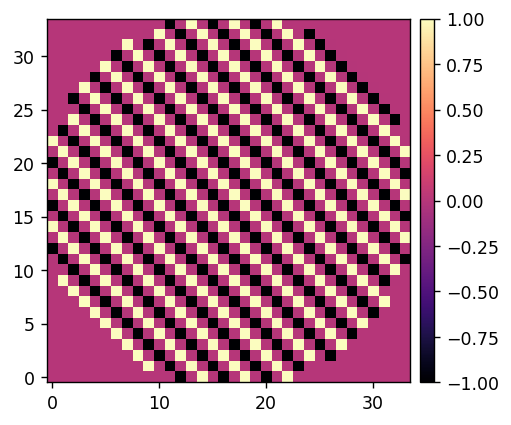

In [ ]:
reload(dm)

fourier_mode = ensure_np_array( dm.make_fourier_command(x_cpa=17/2, y_cpa=0, phase=0) * xp.array(dm_mask) )
# fourier_mode = ensure_np_array( dm.make_fourier_command(x_cpa=17/2, y_cpa=17/2, phase=0) * xp.array(dm_mask) )
utils.imshow(
    [fourier_mode]
)

In [65]:
fourier_mode = ensure_np_array( dm.make_fourier_command(x_cpa=0, y_cpa=17/2, phase=0) * xp.array(dm_mask) )
scoobi.set_dm(dm01_stream, 20e-9 * fourier_mode)

In [67]:
scoobi.zero_dm(dm01_stream)